# Interpret the results on mouse brain data

In [1]:
import os
import sys
sys.path.append("../")
device = "cuda"
import importlib
import scipy as sp

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np
import multiprocessing
import pickle as pkl
import torch
import gc
import sklearn.metrics

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from joblib import Parallel, delayed

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

In [3]:
import steamboat as sf
import steamboat.tools
# importlib.reload(spaceformer.benchmarks)

## Astro-Epen in different regions

In [ ]:
adata = sc.read_h5ad("tmp_adata/mmbrain_0.h5ad")
adatas = [adata]

In [ ]:
model = sf.Steamboat(adatas[0].var_names.tolist(), n_heads=50, n_scales=3)
model = model.to(device)
model.load_state_dict(torch.load('../data/saved_models/mmbrain.pth', weights_only=True), strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['spatial_gather.w_local._scale', 'spatial_gather.w_global._scale'])

In [6]:
pd.crosstab(adata.obs['class'], adata.obs['parcellation_division'])

parcellation_division,CTXsp,HPF,HY,Isocortex,MB,OLF,TH,V3,VL,brain-unassigned,cm,fiber tracts-unassigned,lfbs,mfbs,scwm,unassigned
class,,,,,,,,,,,,,,,,
01 IT-ET Glut,372,1887,0,2983,0,357,0,0,3,8,0,4,17,21,6,0
02 NP-CT-L6b Glut,23,8,1,671,0,0,0,0,0,0,0,0,6,17,38,1
03 OB-CR Glut,2,36,0,1,0,5,0,0,0,0,0,0,0,0,0,3
04 DG-IMN Glut,2,591,0,0,0,4,0,0,0,0,0,1,19,5,0,0
05 OB-IMN GABA,3,1,0,0,0,0,0,0,0,1,0,0,25,3,0,0
06 CTX-CGE GABA,33,82,0,162,0,29,0,0,0,0,0,0,4,8,4,1
07 CTX-MGE GABA,70,221,0,325,0,45,0,0,1,3,0,4,7,16,6,0
08 CNU-MGE GABA,2,0,0,3,0,0,0,0,0,0,0,0,2,1,0,0
09 CNU-LGE GABA,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
adata.obs['class'].value_counts()

class
31 OPC-Oligo         6676
01 IT-ET Glut        5658
30 Astro-Epen        5128
33 Vascular          4975
34 Immune            1436
02 NP-CT-L6b Glut     765
07 CTX-MGE GABA       698
04 DG-IMN Glut        622
16 HY MM Glut         534
18 TH Glut            434
19 MB Glut            350
06 CTX-CGE GABA       323
14 HY Glut            208
12 HY GABA            183
20 MB GABA            133
25 Pineal Glut         51
03 OB-CR Glut          47
05 OB-IMN GABA         33
13 CNU-HYa Glut        17
21 MB Dopa              9
08 CNU-MGE GABA         8
11 CNU-HYa GABA         5
09 CNU-LGE GABA         2
23 P Glut               1
29 CB Glut              1
32 OEC                  1
Name: count, dtype: int64

In [8]:
sc.pl.palettes.vega_20_scanpy

['#1f77b4',
 '#ff7f0e',
 '#279e68',
 '#d62728',
 '#aa40fc',
 '#8c564b',
 '#e377c2',
 '#b5bd61',
 '#17becf',
 '#aec7e8',
 '#ffbb78',
 '#98df8a',
 '#ff9896',
 '#c5b0d5',
 '#c49c94',
 '#f7b6d2',
 '#dbdb8d',
 '#9edae5',
 '#ad494a',
 '#8c6d31']

In [9]:
regions = ["Isocortex", "HPF", "OLF", "CTXsp", "lfbs", "VL", "mfbs", "scwm", "TH", "cm", "MB", "HY", "V3"]
region2color = dict(zip(regions, sc.pl.palettes.vega_20_scanpy[:len(regions)]))

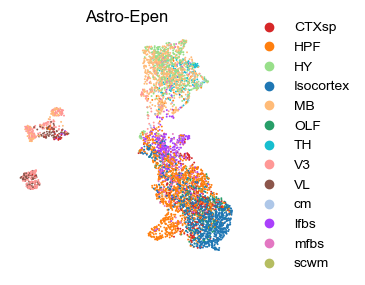

In [ ]:
i = '30 Astro-Epen'

sub_adata = adata[adata.obs['class'] == i]
sub_adata = sub_adata[sub_adata.obs['parcellation_division'].isin(regions)]
sc.pp.neighbors(sub_adata, n_neighbors=10, use_rep='local_attn', key_added='local_attn_neighbors', metric='cosine')
sc.tl.umap(sub_adata, neighbors_key='local_attn_neighbors')

fig, ax = plt.subplots(figsize=(3, 3))
sc.pl.umap(sub_adata, color='parcellation_division', palette=region2color, ax=ax, title='Astro-Epen', frameon=False, size=7.5, show=False)

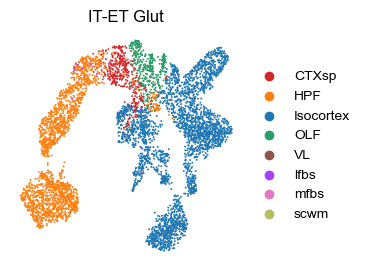

In [ ]:
i = '01 IT-ET Glut'
sub_adata = adata[adata.obs['class'] == i]
sub_adata = sub_adata[sub_adata.obs['parcellation_division'].isin(regions)]
sc.pp.neighbors(sub_adata, n_neighbors=10, use_rep='local_attn', key_added='local_attn_neighbors', metric='cosine')
sc.tl.umap(sub_adata, neighbors_key='local_attn_neighbors')

fig, ax = plt.subplots(figsize=(3, 3))
sc.pl.umap(sub_adata, color='parcellation_division', palette=region2color, ax=ax, title='IT-ET Glut', frameon=False, size=7.5, show=False)

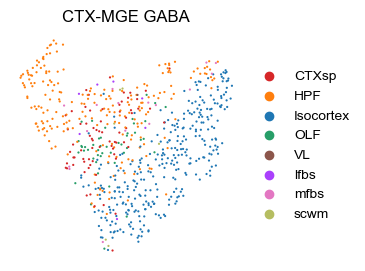

In [ ]:
i = '07 CTX-MGE GABA'
sub_adata = adata[adata.obs['class'] == i]
sub_adata = sub_adata[sub_adata.obs['parcellation_division'].isin(regions)]
sc.pp.neighbors(sub_adata, n_neighbors=10, use_rep='local_attn', key_added='local_attn_neighbors', metric='cosine')
sc.tl.umap(sub_adata, neighbors_key='local_attn_neighbors')

fig, ax = plt.subplots(figsize=(3, 3))
sc.pl.umap(sub_adata, color='parcellation_division', palette=region2color, ax=ax, title='CTX-MGE GABA', frameon=False, size=10, show=False)

In [13]:
class_count_series = adata.obs['class'].value_counts()
classes = class_count_series[class_count_series > 400].index.tolist()

dist_list = []
label = []
group = []

for i in classes:
    sub_adata = adata[adata.obs['class'] == i]
    for region in regions:
        sub_sub_adata = sub_adata[sub_adata.obs['parcellation_division'] == region]
        if len(sub_sub_adata) < 1:
            continue
        inner_dist = sp.spatial.distance.pdist(sub_sub_adata.obsm['local_attn'], metric='euclidean')
        dist_list.extend(inner_dist)
        label.extend([i] * len(inner_dist))
        group.extend(['same-region'] * len(inner_dist))

    for region1 in regions:
        for region2 in regions:
            if region1 == region2:
                continue
            sub_sub_adata1 = sub_adata[sub_adata.obs['parcellation_division'] == region1]
            sub_sub_adata2 = sub_adata[sub_adata.obs['parcellation_division'] == region2]
            if len(sub_sub_adata1) < 1 or len(sub_sub_adata2) < 1:
                continue
            inter_dist = sp.spatial.distance.cdist(sub_sub_adata1.obsm['local_attn'], sub_sub_adata2.obsm['local_attn'], metric='euclidean').flatten()
            dist_list.extend(inter_dist)
            label.extend([i] * len(inter_dist))
            group.extend(['cross-region'] * len(inter_dist))

In [14]:
all_df = pd.DataFrame({'Label': label, 'Distance': dist_list, 'Group': group})
np.random.seed(0)
plot_df = all_df.groupby(['Label', 'Group']).sample(n=2000, replace=True).sort_values('Label')

In [15]:
test_results = {'label': [], 'f_statistic': [], 'p_value': []}
for i in all_df['Label'].unique():
    sub_df = all_df[all_df['Label'] == i]
    sub_df_same = sub_df[sub_df['Group'] == 'same-region']
    sub_df_diff = sub_df[sub_df['Group'] == 'cross-region']
    result = sp.stats.mannwhitneyu(sub_df_same['Distance'], sub_df_diff['Distance'], alternative='two-sided')
    test_f = result.statistic / (len(sub_df_same) * len(sub_df_diff))
    test_p = result.pvalue
    test_results['label'].append(i)
    test_results['f_statistic'].append(test_f)
    test_results['p_value'].append(test_p)
    print(f"{i}: f = {test_f}, p-value = {test_p}")

31 OPC-Oligo: f = 0.3928834250449027, p-value = 0.0
01 IT-ET Glut: f = 0.19035861370790275, p-value = 0.0
30 Astro-Epen: f = 0.24176194267839599, p-value = 0.0
33 Vascular: f = 0.41571368119791, p-value = 0.0
34 Immune: f = 0.3951127087486104, p-value = 0.0
02 NP-CT-L6b Glut: f = 0.42754870338881007, p-value = 0.0
07 CTX-MGE GABA: f = 0.4449206639509035, p-value = 0.0
04 DG-IMN Glut: f = 0.30691415373975034, p-value = 0.0
16 HY MM Glut: f = 0.4671057786652879, p-value = 3.3963607889824387e-43
18 TH Glut: f = 0.41583182827370535, p-value = 0.0


C:\Users\lshh\AppData\Local\Temp\ipykernel_35528\3137004123.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([i.round(2) for i in ax.get_yticks()], fontsize=8)
C:\Users\lshh\AppData\Local\Temp\ipykernel_35528\3137004123.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([i.get_text().split(' ', 1)[1] for i in ax.get_xticklabels()], rotation=30, ha='right', rotation_mode='anchor', fontsize=8)


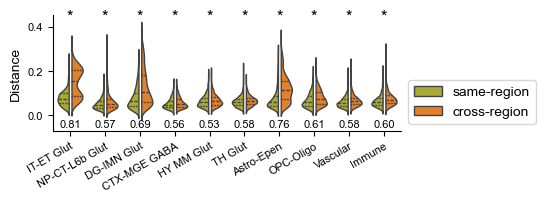

In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 1.5))
sns.violinplot(
        data=plot_df,
        x="Label",
        y="Distance",
        hue=plot_df["Group"].tolist(),                    # when you have hue
        split=True,
        hue_order=["same-region", "cross-region"], # set hue_order with cat instead of bool
        inner='quart',
        density_norm='width',
        gap=.2,
        palette=['C8', 'C1'],
        linewidth=1.,
        ax=ax,
    )
plt.xticks(rotation=30, ha='right', rotation_mode='anchor')
plt.ylim(-0.07, 0.451)

test_df = pd.DataFrame(test_results).sort_values('label').reset_index(drop=True)
for idx, row in test_df.iterrows():
    label = row['label']
    f_statistic = 1 - row['f_statistic']
    p_value = row['p_value']
    annotation = ''
    if p_value < 1e-10:
        annotation = '*'
    annotation2 = '{:.2f}'.format(f_statistic)
    ax.text(idx, 0.41, annotation, ha='center', va='bottom', fontsize=12)
    ax.text(idx, -0.065, annotation2, ha='center', va='bottom', fontsize=8)

ax.set_yticklabels([i.round(2) for i in ax.get_yticks()], fontsize=8)
ax.set_xticklabels([i.get_text().split(' ', 1)[1] for i in ax.get_xticklabels()], rotation=30, ha='right', rotation_mode='anchor', fontsize=8)
ax.set_xlabel('')
for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

sns.move_legend(ax, "lower left", bbox_to_anchor=(1, 0))